In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
from dataclasses import dataclass
import math
from typing import Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from itertools import count
from tqdm import tqdm

/home/emc21/miniconda3/envs/GNN_Env/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Connect4:

    def __init__(self):
        self.height = 6 # height of board
        self.width = 7  # width of board
        # array that stores the board state
        self.board_state = np.zeros((self.height, self.width), dtype=np.int8) 
        self.players = {1: 1, 2: 2}
        # is the game over
        self.gameOver = False
        # if the game has finished, did they win, lose or draw?
        self.isWinDrawLoss = {'win': 1, 'draw': -1, 'lose': -1}

    # if there is a 0 in a column then it is an allowed moved
    def get_allowed_moves(self):
        available_cols = []
        for j in range(self.width):
            col = self.board_state[:, j]
            if 0 in col:
                available_cols.append(j)
        return available_cols

    # check if move is allowed, if so make the move
    def make_move(self, m, player):

        if m in self.get_allowed_moves():
            col = self.board_state[:, m]
            open_slot = np.argmax(col != 0) - 1
            self.board_state[open_slot, m] = self.players[player]

        # check if win draw loss or still playing 
        isWinDrawLoss = self.check_game_done(player)

        return self.board_state.copy(), isWinDrawLoss

    # given a list of numbers, check if there is 4 or more in a row of a certain type
    def checkHas4InARow(self, arr, player):

        current_val = arr[0]
        current_count = 1

        longest_val = arr[0]
        longest_count = 1

        for val in arr[1:]:

            if val == current_val:
                current_count += 1
            else:
                current_val = val
                current_count = 1

            if current_count > longest_count:
                longest_count = current_count
                longest_val = current_val

        if (longest_val == player) and (longest_count >= 4):
            return True

        return False

    # loop over all possible vertical, horizontal and diagonals and check if there 
    # are 4 in a row
    def check_game_done(self, player):

        # check if it is a draw first, as if it is a draw then there is no need to check for 4 in a row
        if np.sum(self.board_state == 0) == 0:
            self.gameOver = True
            return self.isWinDrawLoss['draw']

        # if not a draw, check if there is 4 in a row for the player
        # check if 4 consecutive 1s or 2s
        for i in range(self.width):
            col = self.board_state[:,i]
            has4 = self.checkHas4InARow(col, player)
            if has4:
                self.gameOver = True

        # now check the rows
        for i in range(self.height):
            row = self.board_state[i,:]
            has4 = self.checkHas4InARow(row, player)
            if has4:
                self.gameOver = True

        # now check the diagonals
        # Start with right diagonals, so start from the bottom left corner and move up to the right
        # The starting points are given by the x's shown below:
        #   - - - - - - -
        #   - - - - - - -
        #   - - - - - - -
        #   x x x - - - -
        #   x x x - - - -
        #   x x x - - - -
        for col_idx in range(0, 4):
            for row_idx in range(3, 6):
                right_diagonal = [self.board_state[row_idx - d, col_idx + d] for d in range(4)]
                has4 = self.checkHas4InARow(right_diagonal, player)
                if has4:
                    self.gameOver = True
        # Now do left diagonals
        # The starting points are given by the x's shown below:
        #   - - - - - - -
        #   - - - - - - -
        #   - - - - - - -
        #   - - - - x x x
        #   - - - - x x x
        #   - - - - x x x
        for col_idx in range(3, 7):
            for row_idx in range(3, 6):
                left_diagonal = [self.board_state[row_idx - d, col_idx - d] for d in range(4)]
                has4 = self.checkHas4InARow(left_diagonal, player)
                if has4:
                    self.gameOver = True

        if self.gameOver:
            return self.isWinDrawLoss['win']
        else:
            return 0.


    def render(self):
        rendered_board_state = self.board_state.copy().astype(np.str)
        rendered_board_state[self.board_state == 0] = ' '
        rendered_board_state[self.board_state == 1] = 'O'
        rendered_board_state[self.board_state == 2] = 'X'
        # display(pd.DataFrame(rendered_board_state))

    def reset(self):
        self.__init__()

board = Connect4()

# show an example of some moves 
print("Initial board state:")
print(board.board_state)

# make a move 
new_state, reward = board.make_move(3, 1)
print("\nBoard state after player 1 moves in column 3:")
print(new_state)
print(f"Reward for player 1: {reward}")

# reset the board 
board.reset()


Initial board state:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]

Board state after player 1 moves in column 3:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]]
Reward for player 1: 0.0


In [3]:
@dataclass
class Transition:
    state:      object   # e.g. np.ndarray (N,M)
    action:     int
    reward:     float
    next_state: object   # np.ndarray or None
    done:       bool

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.memory = deque(maxlen=capacity)

    def add(self, tr: Transition):
        self.memory.append(tr)

    def sample(self, batch_size: int):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

replay_buffer = ReplayBuffer(100_000)

In [4]:

class RelativePositionBias2D(nn.Module):
    """
    Learned relative bias for a fixed 2D grid, added to attention logits.
    Produces bias of shape (1, H, S, S) where S = 1 + (R*C) includes CLS.
    """
    def __init__(self, num_heads: int, n_rows: int, n_cols: int, include_cls: bool = True):
        super().__init__()
        self.num_heads = num_heads
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.include_cls = include_cls

        self.dr = 2 * (n_rows - 1) + 1  # 11 for rows=6
        self.dc = 2 * (n_cols - 1) + 1  # 13 for cols=7
        self.num_buckets = self.dr * self.dc  # 143

        # (H, num_buckets)
        self.bias_table = nn.Parameter(torch.zeros(num_heads, self.num_buckets))
        nn.init.normal_(self.bias_table, std=0.02)

        # Precompute pairwise bucket indices for the grid tokens (no CLS)
        coords = [(r, c) for r in range(n_rows) for c in range(n_cols)]
        coords = torch.tensor(coords, dtype=torch.long)  # (RC, 2)

        rel = coords[:, None, :] - coords[None, :, :]    # (RC, RC, 2) = (i-j)
        rel_r = rel[..., 0] + (n_rows - 1)               # shift to [0..dr-1]
        rel_c = rel[..., 1] + (n_cols - 1)               # shift to [0..dc-1]
        bucket = rel_r * self.dc + rel_c                 # (RC, RC) in [0..num_buckets-1]

        if include_cls:
            S = 1 + n_rows * n_cols
            full = torch.zeros(S, S, dtype=torch.long)
            full[1:, 1:] = bucket
            # CLS interactions: leave as 0 bucket (or make separate if you want)
            self.register_buffer("bucket_index", full, persistent=False)  # (S,S)
        else:
            self.register_buffer("bucket_index", bucket, persistent=False)  # (RC,RC)

    def forward(self):
        # bias_table: (H, B)
        # bucket_index: (S, S)
        # => (H, S, S)
        bias = self.bias_table[:, self.bucket_index]  # advanced indexing
        return bias.unsqueeze(0)  # (1, H, S, S)
    
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, relpos_bias: nn.Module = None):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.relpos_bias = relpos_bias  # may be None

    def scaled_dot_product_attention(self, Q, K, V, mask=None, return_attn: bool = False):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B,H,S,S)

        # Add relative bias if provided (broadcast over batch)
        if self.relpos_bias is not None:
            attn_scores = attn_scores + self.relpos_bias()  # (1,H,S,S) -> broadcast to (B,H,S,S)

        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)

        if return_attn:
            return output, attn_probs
        return output

    def split_heads(self, x):
        batch_size, seq_length, _ = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None, return_attn: bool = False):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        if return_attn:
            attn_output, attn_probs = self.scaled_dot_product_attention(Q, K, V, mask, return_attn=True)
            output = self.W_o(self.combine_heads(attn_output))
            return output, attn_probs

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output
    
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, relpos_bias=None):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.mha = MultiHeadAttention(d_model, num_heads, relpos_bias=relpos_bias)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None, return_attn: bool = False):
        y = self.ln1(x)
        if return_attn:
            mha_out, attn = self.mha(y, y, y, attn_mask, return_attn=True)
            x = x + self.dropout(mha_out)
            x = x + self.dropout(self.ffn(self.ln2(x)))
            return x, attn

        x = x + self.dropout(self.mha(y, y, y, attn_mask))
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x


class TransformerDQN(nn.Module):
    """
    Connect-k policy network that selects a COLUMN action.

    Required inputs:
      board: LongTensor (B, N, M) with values {0,1,2}
        0 = empty, 1 = player1 piece, 2 = player2 piece

      player_to_move: LongTensor (B,) with values {0,1}
        0 = player1 to move, 1 = player2 to move

    Outputs:
      logits:        (B, M) raw logits over columns (unmasked)
      masked_logits: (B, M) logits with invalid columns set to -1e9 (safe for softmax/CE)
      valid_mask:    (B, M) boolean; True means column is playable (not full)
    """
    def __init__(
        self,
        d_model: int = 128,
        num_heads: int = 4,
        num_layers: int = 4,
        d_ff: int = 128,
        dropout: float = 0,
    ):
        super().__init__()
        self.n_rows = 6
        self.n_cols = 7
        self.seq_len = self.n_rows * self.n_cols
        self.d_model = d_model

        # Categorical embedding for cell states {0,1,2}
        self.cell_embed = nn.Embedding(3, d_model)

        # 2D learned positional embeddings (row + col)
        self.row_embed = nn.Embedding(self.n_rows, d_model)
        self.col_embed = nn.Embedding(self.n_cols, d_model)

        # CLS token is ALWAYS used
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)

        self.relpos_bias = RelativePositionBias2D(
            num_heads=num_heads,
            n_rows=self.n_rows,
            n_cols=self.n_cols,
            include_cls=True,
        )

        self.layers = nn.ModuleList(
            [TransformerEncoderLayer(d_model, num_heads, d_ff, dropout, relpos_bias=self.relpos_bias)
            for _ in range(num_layers)]
        )

        self.final_ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Policy head: one logit per column action (0..M-1)
        self.policy_head = nn.Linear(d_model, self.n_cols)

    @staticmethod
    def compute_valid_action_mask(board: torch.Tensor) -> torch.Tensor:
        """
        A column is valid if its TOP cell is empty (gravity connect-style).
        Assumes row index 0 is the TOP row, as in your examples.

        board: (B,N,M) values {0,1,2}
        returns: (B,M) bool
        """
        top_row = board[:, 0, :]  # (B,M)
        return top_row == 0

    def forward(
        self,
        board: torch.Tensor,
        valid_action_mask: Optional[torch.Tensor] = None,
        return_attn: bool = False,
    ):
        B, N, M = board.shape

        x = self.cell_embed(board)

        rows = torch.arange(self.n_rows, device=board.device).unsqueeze(1).expand(self.n_rows, self.n_cols)
        cols = torch.arange(self.n_cols, device=board.device).unsqueeze(0).expand(self.n_rows, self.n_cols)
        pos = self.row_embed(rows) + self.col_embed(cols)
        x = x + pos.unsqueeze(0)

        x = x.view(B, self.seq_len, self.d_model)

        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.dropout(x)

        attn_maps = []  # list of (B,H,S,S) if return_attn
        for layer in self.layers:
            if return_attn:
                x, attn = layer(x, return_attn=True)
                attn_maps.append(attn)
            else:
                x = layer(x)

        x = self.final_ln(x)
        h = x[:, 0, :]
        logits = self.policy_head(h)

        if valid_action_mask is None:
            valid_action_mask = self.compute_valid_action_mask(board)
        else:
            valid_action_mask = valid_action_mask.bool()

        masked_logits = logits.masked_fill(~valid_action_mask, -1e9)

        if return_attn:
            # attn_maps: length = num_layers, each (B,H,S,S) where S = 1 + N*M (CLS + cells)
            return logits, masked_logits, valid_action_mask, attn_maps

        return logits, masked_logits, valid_action_mask


In [5]:
# example of making the model and passing a board through
model = TransformerDQN(
    d_model=64,
    num_heads=8,
    num_layers=2,
    d_ff=128,
    dropout=0,
)

print("Model = ")
print(model)

# Example board
board_example = torch.zeros(6, 7, dtype=torch.long).unsqueeze(0)  # (B=1, N=6, M=7)
print(f"\n\nEmpty board:")
print(board_example)

logits, masked_logits, valid_mask = model(board_example)

probs = torch.softmax(masked_logits, dim=-1)
action = torch.argmax(probs, dim=-1)

print("\n\nValid mask:", valid_mask)
print("Action probabilities:", probs)
print("Chosen column:", action.item())

Model = 
TransformerDQN(
  (cell_embed): Embedding(3, 64)
  (row_embed): Embedding(6, 64)
  (col_embed): Embedding(7, 64)
  (relpos_bias): RelativePositionBias2D()
  (layers): ModuleList(
    (0): TransformerEncoderLayer(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
        (relpos_bias): RelativePositionBias2D()
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU()
        (2): Dropout(p=0, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0, inplace=False)
    )
    (1): Transform

In [6]:
# initialise the models

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

policy_net = TransformerDQN().to(device)
print(f"Policy net parameters: {sum(p.numel() for p in policy_net.parameters())}")
# target_net will be updated every n episodes to tell policy_net a better estimate of how far off from convergence
target_net = TransformerDQN().to(device)
target_net.load_state_dict(policy_net.state_dict())
# set target_net in testing mode
target_net.eval()

cpu
Policy net parameters: 402243


TransformerDQN(
  (cell_embed): Embedding(3, 128)
  (row_embed): Embedding(6, 128)
  (col_embed): Embedding(7, 128)
  (relpos_bias): RelativePositionBias2D()
  (layers): ModuleList(
    (0): TransformerEncoderLayer(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (relpos_bias): RelativePositionBias2D()
      )
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): GELU()
        (2): Dropout(p=0, inplace=False)
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0, inplace=False)
    )
    (1): Tra

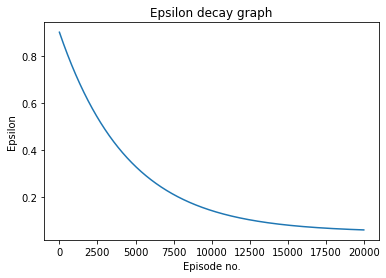

In [7]:
# epilson decay graph
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 4500

steps_done = np.arange(20000)
eps = EPS_END + (EPS_START - EPS_END) * np.exp(-1 * steps_done / EPS_DECAY)
plt.plot(steps_done, eps)
plt.title('Epsilon decay graph')
plt.xlabel('Episode no.')
plt.ylabel('Epsilon')
plt.show()

In [8]:
# functions for selecting actions for the model and opponent (random) policy

def select_action(state, available_actions, steps_done=None, training=True):

    state = torch.tensor(state, dtype=torch.long).to(device).unsqueeze(dim=0)

    epsilon = random.random()
    if training:
        eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1 * steps_done / EPS_DECAY)
    else:
        eps_threshold = 0

    # follow epsilon-greedy policy
    if epsilon > eps_threshold:
        with torch.no_grad():
            # action recommendations from policy net
            logits, masked_logits, valid_action_mask = policy_net(state) # (B,M), (B,M), (B,M)
            greedy_action = torch.argmax(masked_logits[0])
            return greedy_action.item()

    else:
        return random.choice(available_actions)

# random agent
def random_agent(actions):
    return random.choice(actions)

# reward function 
def reward_function(n_moves, outcome):
    if outcome == 'win':
        reward = 1 - (n_moves - 7) * (0.8 / (42 - 7))
    elif outcome == 'draw':
        reward = 0.2 - (n_moves - 7) * (0.4 / (42 - 7))
    elif outcome == 'loss':
        reward = -1 + (n_moves - 7) * (0.8 / (42 - 7))
    else:
        raise ValueError("Invalid outcome")

    return reward

In [9]:
# win rate test
def win_rate_test():
    win_moves_taken_list = []
    win = []
    for i in range(100):
        board.reset()
        win_moves_taken = 0

        while not board.gameOver:
            state = board.board_state.copy()
            available_actions = board.get_allowed_moves()
            action = select_action(state, available_actions, training=False)
            state, reward = board.make_move(action, 1)
            win_moves_taken += 1

            if reward == 1:
                win_moves_taken_list.append(win_moves_taken)
                win.append(1)
                break

            available_actions = board.get_allowed_moves()
            action = random_agent(available_actions)
            state, reward = board.make_move(action, 2)

    return sum(win)/100, sum(win_moves_taken_list)/len(win_moves_taken_list)


In [10]:
# set up training hyperparameters 
BATCH_SIZE = 256
GAMMA = 0.999

# initialise the optimizer
optimizer = optim.Adam(policy_net.parameters())

In [11]:
def optimise_model():
    if len(replay_buffer) < BATCH_SIZE:
        return

    transitions = replay_buffer.sample(BATCH_SIZE)

    # first get all the states, actions, rewards, next_states in the batch of transitions
    # but we need to make sure that the final state has a Q value of 0, so we use masking
    state_batch = []
    action_batch = []
    reward_batch = []
    not_final_next_state_batch = []
    not_final_state_mask = []

    for tran in transitions:
        state_batch.append(tran.state)
        action_batch.append([tran.action])
        reward_batch.append(tran.reward)
        if tran.next_state is not None:
            not_final_next_state_batch.append(tran.next_state)
            not_final_state_mask.append(True)
        else:
            not_final_state_mask.append(False)

    state_batch = torch.tensor(np.array(state_batch), dtype=torch.long, device=device)
    action_batch = torch.tensor(np.array(action_batch), dtype=torch.long, device=device)
    reward_batch = torch.tensor(np.array(reward_batch), dtype=torch.float, device=device)
    not_final_next_state_batch = torch.tensor(np.array(not_final_next_state_batch), dtype=torch.long, device=device)
    not_final_state_mask = torch.tensor(not_final_state_mask, device=device)
    
    # prediction from policy_net
    logits, masked_logits, valid_action_mask = policy_net(state_batch)
    # get the logit corresponding to the action taken in the transition for each state in the batch
    state_action_values = masked_logits.gather(1, action_batch)

    # truth from target_net, initialize with zeros since terminal state value = 0
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    # tensor.detach() creates a tensor that shares storage with tensor that does not require grad
    target_logits, target_masked_logits, target_valid_action_mask = target_net(not_final_next_state_batch)
    next_state_values[not_final_state_mask] = target_masked_logits.max(1)[0].detach()
    # compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1)) # torch.tensor.unsqueeze returns a copy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [12]:
# Now train! 
# avoid resetting
steps_done = 0
training_history = []

In [13]:

num_episodes = 100
# control how lagged is target network by updating every n episodes
TARGET_UPDATE = 10

for i in tqdm(range(num_episodes)):

    # record model performance every 40 epochs
    if i % 40 == 39:
        win_rate, moves_taken = win_rate_test()
        training_history.append([i + 1, win_rate, moves_taken])
        th = np.array(training_history)

        # print training message every 200 epochs
        if i % 200 == 199:
            print('Episode {}: | win_rate: {} | moves_taken: {}'.format(i, th[-1, 1], th[-1, 2]))

    # start with a fresh board
    board.reset()
    state_p1 = board.board_state.copy()
    
    # loop over until the game is finished
    for t in count():
        # player 1 moves (our model)
        available_actions = board.get_allowed_moves()
        action_p1 = select_action(state_p1, available_actions, steps_done)
        steps_done += 1
        state_p1_, isWinDrawLoss_p1 = board.make_move(action_p1, 1)
        
        # check if player 1 has won, or if the previous move led to a draw
        if board.gameOver:
            if isWinDrawLoss_p1 == 1:
                # reward p1 for p1's win
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = reward_function(t, 'win'), next_state = None, done = True))
            else:
                # state action value tuple for a draw
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = reward_function(t, 'draw'), next_state = None, done = True))
            break

        # if the game is still going, player 2 to move
        available_actions = board.get_allowed_moves()
        action_p2 = random_agent(available_actions)
        state_p2_, isWinDrawLoss_p2 = board.make_move(action_p2, 2)
        
        # check if player 2 has won or if the move led to a draw
        if board.gameOver:
            if isWinDrawLoss_p2 == 1:
                # punish p1 for (random agent) p2's win
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = reward_function(t, 'loss'), next_state = None, done = True))
            else:
                # state action value tuple for a draw
                replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = reward_function(t, 'draw'), next_state = None, done = True))
            break

        # If neither won and no draw, then add transition to the buffer and go to player 1 move again
        replay_buffer.add(Transition(state = state_p1, action = action_p1, reward = 0, next_state = state_p2_, done = False))
        state_p1 = state_p2_

        # Perform one step of the optimization (on the policy network)
        # note that this will only actually run if there are enough transitions in the buffer
        optimise_model()

    # update the target network, copying all weights and biases in DQN
    if i % TARGET_UPDATE == TARGET_UPDATE - 1:
        target_net.load_state_dict(policy_net.state_dict())


print('Complete')

100%|██████████| 100/100 [06:06<00:00,  3.67s/it]

Complete


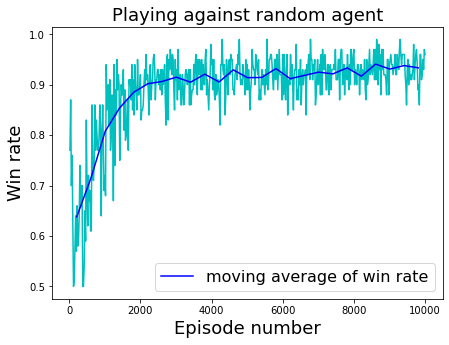

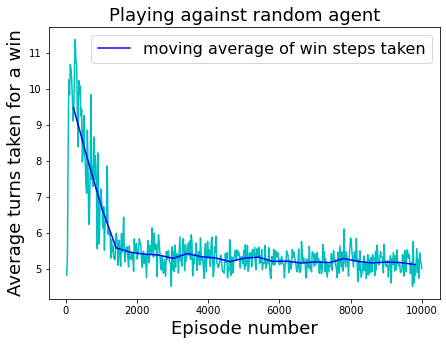

In [43]:
# Show an example of the training history
th = np.load("training_history.npy")

win_rate_moving_average = [np.mean(th[i: i+20, 1]) for i in range(0, len(th), 20)]
mid_points = [(th[i,0] + th[i+19,0]) / 2 for i in range(0, len(th), 20)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Playing against random agent', fontsize=18)
ax.set_xlabel('Episode number', fontsize=18)
ax.set_ylabel('Win rate', fontsize=18)

ax.plot(th[:, 0], th[:, 1], c='c')
ax.plot(mid_points, win_rate_moving_average, c='b', label='moving average of win rate')
plt.legend(fontsize=16)
plt.savefig('win_rate_and_steps.png',
    facecolor='white',
    edgecolor='white',
    transparent=False)

win_steps_moving_average = [np.mean(th[i: i+20, 2]) for i in range(0, len(th), 20)]
mid_points = [(th[i,0] + th[i+19,0]) / 2 for i in range(0, len(th), 20)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title('Playing against random agent', fontsize=18)
ax.set_xlabel('Episode number', fontsize=18)
ax.set_ylabel('Average turns taken for a win', fontsize=18)

ax.plot(th[:, 0], th[:, 2], c='c')
ax.plot(mid_points, win_steps_moving_average, c='b', label='moving average of win steps taken')
plt.legend(fontsize=16)
plt.savefig('number_of_steps.png',
    facecolor='white',
    edgecolor='white',
    transparent=False)

/tmp/ipykernel_221213/3903603414.py:108: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


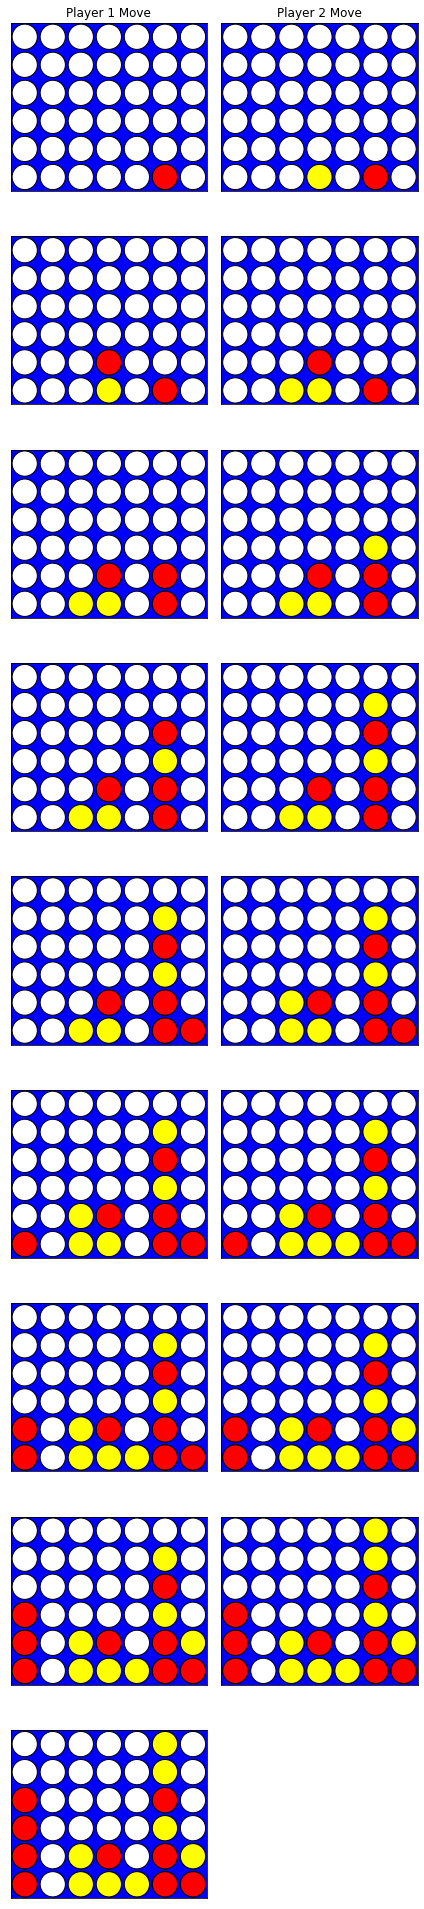

In [15]:
# Demo game

def demoGame():
    board.reset()
    # board.render()

    states = []

    while not board.gameOver:
        state = board.board_state.copy()
        available_actions = board.get_allowed_moves()
        action = select_action(state, available_actions, training=False)
        # trained agent's move is denoted by O
        state, reward = board.make_move(action, 1)
        # board.render()
        states.append(state)

        if reward == 1:
            break

        available_actions = board.get_allowed_moves()
        action = random_agent(available_actions)
        state, reward = board.make_move(action, 2)
        # board.render()
        states.append(state)
    return states


def renderBoard(board_state, ax=None):
    board_state = board_state.copy()[::-1]

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    else:
        fig = ax.figure

    ax.set_xlim(0, 7)
    ax.set_ylim(0, 6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    # Draw blue board
    for r in range(6):
        for c in range(7):
            cell = plt.Rectangle((c, r), 1, 1,
                                 facecolor='blue',
                                 edgecolor='blue')
            ax.add_patch(cell)

    # Draw white holes
    for r in range(6):
        for c in range(7):
            hole = plt.Circle((c + 0.5, r + 0.5),
                              0.45,
                              facecolor='white',
                              edgecolor='black')
            ax.add_patch(hole)

    colors = {1: 'red', 2: 'yellow'}

    # Draw pieces
    for r in range(6):
        for c in range(7):
            if board_state[r, c] != 0:
                piece = plt.Circle((c + 0.5, r + 0.5),
                                   0.45,
                                   facecolor=colors[board_state[r, c]],
                                   edgecolor='black')
                ax.add_patch(piece)

    return fig, ax


# Run a demo game and then plot the states
states = demoGame()

# plot of grid of 2 columns and N rows (depending on len(states))
num_states = len(states)
cols = 2
rows = (num_states + 1) // cols

n_plots = rows * cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3), constrained_layout=True)

for i in range(n_plots):
    r = i // cols
    c = i % cols

    if i >= len(states):
        # delete this subplot
        axes[r, c].remove()
        # axes[r, c].set_xlim(0, 7)
        # axes[r, c].set_ylim(0, 6)
        # axes[r, c].set_xticks([])
        # axes[r, c].set_yticks([])
        continue

    state = states[i]
    ax = axes[r, c]

    renderBoard(state, ax=ax)

axes[0, 0].set_title(f"Player 1 Move")
axes[0, 1].set_title(f"Player 2 Move")
plt.tight_layout()
# minimise space between subplots
# plt.subplots_adjust(wspace=0.1, hspace=-0.6)
plt.show()